In [3]:
import os
import sys
sys.path.insert(0, "/hkfs/work/workspace/scratch/cc7738-automorphism/ANP4Link/")

# === Standard Library ===
import random
from collections import defaultdict, Counter
from typing import Optional

# === Third-Party Libraries ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import torch
from torch import Tensor
from torch_geometric.data import Data
from torch_geometric.datasets import Planetoid, Amazon
from torch_geometric.nn import WLConv
from torch_geometric.typing import Adj
from torch_geometric.utils import (
    degree,
    is_sparse,
    scatter,
    sort_edge_index,
    to_edge_index,
    from_networkx,
    to_networkx,
    train_test_split_edges,
    to_undirected
)
from scipy.stats import qmc
import pynauty

# === Project-Specific Modules ===
from syn_graph.graph_generation import GraphType, generate_graph
from syn_graph.syn_random import RegularTilling, init_regular_tilling
from syn_real.custom_wl import WLConvOptimized
from syn_real.mot import (
    run_wl_test_and_group_nodes,
    compute_automorphism_metrics,
    count_orbit_edges,
    plot_orbit_dist,
    plot_orbit,
    plot_triangular_graph
)
import argparse


def get_graph_orbits(graph: nx.Graph) -> list:
    # Map nodes to consecutive indices
    node_mapping = {node: idx for idx, node in enumerate(graph.nodes())}
    
    # Create adjacency dictionary with remapped indices
    adj_dict = {
        node_mapping[node]: [node_mapping[neighbor] for neighbor in graph.neighbors(node)]
        for node in graph.nodes()
    }
    
    # Construct pynauty graph
    n = len(graph.nodes())
    G_pynauty = pynauty.Graph(number_of_vertices=n, adjacency_dict=adj_dict, directed=False)
    
    # Compute orbits
    _, _, _, orbits, num_orbit = pynauty.autgrp(G_pynauty)
    
    return orbits, num_orbit



/home/hk-project-test-p0021478/cc7738/anaconda3/envs/EAsF/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def plot_orbit_dist(orbits):
    node_groups = {}
    for node, label in enumerate(orbits):
        if label not in node_groups:
            node_groups[label] = []
        node_groups[label].append(node)
        
    group_sizes = np.array([len(group) for group in node_groups.values()])
    plt.figure(figsize=(6, 4))
    plt.hist(group_sizes, bins=range(min(group_sizes), max(group_sizes) + 2), align='left', rwidth=0.8)
    plt.xlabel('Orbit Size')
    plt.ylabel('Frequency of Orbit Sizes')
    plt.title('Histogram of Orbit Distribution')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    # plt.savefig(f"{name}_distribution_d{depth}.pdf")
    plt.close()



def plot_orbit(orbits):
    plt.figure(figsize=(6, 4))
    plt.hist(orbits, bins=range(min(orbits), max(orbits) + 2), align='left', rwidth=0.8)
    plt.xlabel('Orbit Label')
    plt.ylabel('Frequency')
    plt.title('Orbit Distribution')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    # plt.savefig(f"{name}_distribution_d{depth}.pdf")
    plt.close()

In [5]:
def plot_triangular_graph(G, 
                          orbits, 
                          custom_labels=None, 
                          figsize=(8, 6), 
                          cmap='Blues'):
    """
    Plots a triangular lattice graph with node coloring based on orbit labels.

    Parameters:
        G (nx.Graph): The triangular lattice graph to plot.
        orbits (list or dict): Orbit label for each node.
        custom_labels (dict, optional): Custom labels for nodes.
        figsize (tuple): Size of the figure.
        cmap (str): Matplotlib colormap name.
    """

    plt.figure(figsize=(6, 6))
    labels = {}
    for i, node in enumerate(G.nodes()):
        labels.update({node: orbits[i].item()})
    nx.draw(
        G,
        # node_color=orbits, 
        with_labels=True,
        labels=labels,
        node_size=1500,       # Increase node size (default is ~300–600)
        edgecolors='black',
        font_weight='bold',
        font_size=14          
    )

    plt.title("Graph Colored by Float Values", fontsize=16) 
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    plt.close()

In [6]:

def plot_graph_with_orbits(G, pos, orbits, custom_labels=None, figsize=(8, 6), cmap='tab20b'):
    """
    Plots a NetworkX graph with node coloring based on orbit labels.
    
    Parameters:
        G (nx.Graph): The graph to plot.
        pos (dict): Node positions.
        orbits (list or array): Orbit label for each node.
        custom_labels (dict, optional): Dictionary of node labels.
        figsize (tuple): Figure size for the plot.
        cmap (str): Matplotlib colormap for nodes.
    """
    plt.figure(figsize=figsize)
    node_colors = [orbits[node] for node in G.nodes()]
    nx.draw(
        G,
        pos=pos,
        labels=custom_labels,
        node_color=node_colors,
        cmap=cmap,
        node_size=500,
        font_weight='bold',
        edgecolors='black'
    )
    plt.title("Graph Colored by Orbit Labels")
    plt.show()
    plt.close()

In [7]:

def create_disjoint_graph(data):
    """
    Creates two disjoint copies of a real-world graph (e.g., Cora).
    Args:
        data (Data): PyG Data object representing the original graph.
    Returns:
        Data: PyG Data object representing the new merged graph.
    """
    num_nodes = data.num_nodes
    G = to_networkx(data, to_undirected=True)
    G2 = nx.relabel_nodes(G, lambda x: x + num_nodes)
    merged_graph = nx.compose(G, G2)
    merged_data = from_networkx(merged_graph)
    merged_data.edge_index = torch.cat([merged_data.edge_index, torch.tensor([num_nodes-1, num_nodes-1 + num_nodes]).unsqueeze(dim=1)], dim=1)
    if hasattr(data, 'x'):
        data.x = torch.ones((data.num_nodes, 16))
    merged_data.x = torch.cat([data.x, data.x], dim=0)
    merged_graph = to_networkx(merged_data, to_undirected=True)
    return merged_data, merged_graph



In [8]:
def semi_syn_graph(G, pos=None):
    # print(f"Processing graph of type {graph_type} with {N} nodes")
    # if graph_type == RegularTilling.SQUARE_GRID:
    #     G, _, _, pos = init_regular_tilling(N, RegularTilling.SQUARE_GRID, seed=None)
    # elif graph_type == 'GraphType.COMPLETE':
    #     graph_type = 'GraphType.COMPLETE'
    #     G = nx.complete_graph(N)
    # else:
    #     G = generate_graph(N, graph_type, seed=0)
    
    # Process Graph with WL Test
    data = from_networkx(G)
    # print(f"Graph type: {graph_type}, Number of nodes: {data.num_nodes}, Number of edges: {data.num_edges}")
    # print(f"Number of nodes in the graph: {data.num_nodes}")
    mdata, mG = create_disjoint_graph(data)
    # print(f"Merged Graph type: {graph_type}, Number of nodes: {mdata.num_nodes}, Number of edges: {mdata.num_edges}")
    print(mdata)

    # check the WL distribution
    _, node_labels, orbits = run_wl_test_and_group_nodes(data.edge_index, num_nodes=data.num_nodes, num_iterations=100)
    custom_labels = {}
    for i, ov in zip(G.nodes(), orbits):
            custom_labels[i] = f"{ov}"
    plot_graph_with_orbits(G, None, orbits, custom_labels=custom_labels, figsize=(8, 6), cmap='tab20b')
    count_orbit_edges(G, node_labels)

    _, mnode_labels, morbits = run_wl_test_and_group_nodes(mdata.edge_index, num_nodes=mdata.num_nodes, num_iterations=100)
    # metrics, num_nodes, group_sizes = compute_automorphism_metrics(node_groups, G.number_of_nodes())

    custom_labels = {}
    for i, ov in zip(mG.nodes(), morbits):
            custom_labels[i] = f"{ov}"
    
    plot_graph_with_orbits(mG, None, morbits, custom_labels=custom_labels, figsize=(8, 6), cmap='tab20b')
    count_orbit_edges(mG, mnode_labels)
    return 

In [9]:
def analyze_automorphisms(G):
    
    data = from_networkx(G)
    # _, node_labels, orbits = run_wl_test_and_group_nodes(data.edge_index, num_nodes=data.num_nodes, num_iterations=100)
    orbits, num_orbit = get_graph_orbits(G)
    # print(f"Number of orbits: {num_orbit}")

    custom_labels = {}
    for i, ov in zip(G.nodes(), orbits):
            custom_labels[i] = f"{ov}"

    count_orbit_edges(G, orbits)
    
    metrics, num_nodes, group_sizes = compute_automorphism_metrics(orbits, G.number_of_nodes())
    
    plot_orbit_dist(orbits)
    plot_orbit(orbits)
    # hash_links_by_orbit(G, orbits)
    plot_graph_with_orbits(G, 
                           None, 
                           orbits, 
                           custom_labels=custom_labels, 
                           figsize=(8, 6), cmap='tab20b')
    return metrics, num_nodes, group_sizes, orbits



In [10]:
# --- 3️⃣ Add Controllable Random Edges ---
def add_random_edges(graph_data, 
                     inter_ratio=0.5, 
                     intra_ratio=0.5, 
                     total_edges=1000):
    """
    Adds random edges between and within two graph copies in a controlled way.

    Args:
        graph_data (Data): The graph structure (PyG format).
        inter_ratio (float): Fraction of edges to add **between** the two graph copies.
        total_edges (int): Total number of random edges to add.

    Returns:
        Data: Graph with additional edges.
    """
    num_nodes = graph_data.num_nodes // 2 
    inter_edges = int(total_edges * inter_ratio)
    intra_edges = int(total_edges * intra_ratio)
    inter_edges_list = [
        (random.randint(0, num_nodes - 1), random.randint(num_nodes, 2 * num_nodes - 1))
        for _ in range(inter_edges)
    ]
    intra_edges_list = []
    for _ in range(intra_edges):
        copy = random.choice([0, 1]) 
        base_offset = num_nodes * copy 
        u, v = random.sample(range(base_offset, base_offset + num_nodes), 2)
        intra_edges_list.append((u, v))
        
    new_edges = torch.tensor(inter_edges_list + intra_edges_list, dtype=torch.long).T
    print(new_edges.shape)
    updated_edge_index = torch.cat([graph_data.edge_index, new_edges], dim=1)
    return Data(edge_index=updated_edge_index, num_nodes=graph_data.num_nodes, x=graph_data.x), updated_edge_index




In [11]:
def semi_autom_test(N, graph_type, pos=None):
    # print(f"Processing graph of type {graph_type} with {N} nodes")
    if graph_type == RegularTilling.SQUARE_GRID:
        G, _, _, pos = init_regular_tilling(N, RegularTilling.SQUARE_GRID, seed=None)
    elif graph_type == 'GraphType.COMPLETE':
        graph_type = 'GraphType.COMPLETE'
        G = nx.complete_graph(N)
    else:
        G = generate_graph(N, graph_type, seed=0)
    
    # Process Graph with WL Test
    data = from_networkx(G)
    # print(f"Graph type: {graph_type}, Number of nodes: {data.num_nodes}, Number of edges: {data.num_edges}")
    # print(f"Number of nodes in the graph: {data.num_nodes}")

    # check the WL distribution
    analyze_automorphisms(G)

    mdata, mG = create_disjoint_graph(data)
    analyze_automorphisms(mG)
    return 


In [12]:
def visualize_orbit_adjacency_matrix(edge_class_counts):
    # Extract all unique orbit IDs
    orbit_ids = sorted(set(i for edge in edge_class_counts for i in edge))
    orbit_to_idx = {orbit: idx for idx, orbit in enumerate(orbit_ids)}
    n = len(orbit_ids)

    # Initialize matrix
    mat = np.zeros((n, n), dtype=int)

    # Fill matrix
    for (a, b), count in edge_class_counts.items():
        i, j = orbit_to_idx[a], orbit_to_idx[b]
        mat[i, j] += count
        mat[j, i] += count if i != j else 0  # symmetric, avoid double-counting diagonals

    # Plot heatmap
    plt.figure(figsize=(6, 5))
    plt.imshow(mat, cmap='Blues', interpolation='nearest')
    plt.title('Orbit Adjacency Matrix')
    plt.xlabel('Orbit ID')
    plt.ylabel('Orbit ID')
    plt.xticks(range(n), orbit_ids)
    plt.yticks(range(n), orbit_ids)
    plt.colorbar(label='Edge Count')
    plt.tight_layout()
    # plt.savefig('orbit_adjacency_matrix.pdf', dpi=300)
    plt.show()



def semi_autom_expt(G, pos=None):

    # Process Graph with WL Test
    data = from_networkx(G)
    print(f"Number of nodes in the graph: {data.num_nodes}")
    analyze_automorphisms(G)
    mdata, mG = create_disjoint_graph(data)
    
    inter_ratio = 0.9
    intra_ratio = 0.5
    total_edges = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]*10
    
    for edges in total_edges:
        print(edges)
        if inter_ratio != 0 and intra_ratio != 0 and total_edges != 0:
            updated_graph_data, new_edges = add_random_edges(mdata, inter_ratio=inter_ratio, total_edges=edges)
        else:
            updated_graph_data = mdata
        
        G = to_networkx(updated_graph_data, to_undirected=True)
        analyze_automorphisms(G)
    return 

In [13]:
def hash_links_by_orbit(G: nx.Graph, orbits: list ):
    """
    Group and count edges by the sorted orbit pairs they connect.

    Args:
        G: networkx.Graph
        node_groups: list of orbit IDs per node (e.g., from WL hashing)

    Returns:
        edge_class_counts: dict with keys (orbit_a, orbit_b), values are counts
        edge_classes: list of (orbit_a, orbit_b) tuples in the same order as G.edges()
    """

    node_to_orbit = orbits# .tolist()
    edge_class_counts = defaultdict(int)
    edge_classes = []

    for u, v in G.edges():
        orbit_u = node_to_orbit[u]
        orbit_v = node_to_orbit[v]
        key = tuple(sorted((orbit_u, orbit_v))) 
        edge_class_counts[key] += 1
        edge_classes.append(key)

    # print(f"Edge class counts: {sorted(edge_class_counts.values())[-10:]}")
    # print(f"Unique Edge classes: {len(set(edge_classes))}")
    # visualize_orbit_adjacency_matrix(edge_class_counts)
    return edge_class_counts, edge_classes

In [14]:
if '__name__' == "__main__":
    parser = argparse.ArgumentParser(description="Semi-automorphism experiment on synthetic graphs")
    parser.add_argument("--graph_type", type=str, default="GraphType.BARABASI_ALBERT", help="Type of graph to generate")
    parser.add_argument("--N", type=int, default=10, help="Number of nodes in the graph")
    args = parser.parse_args()

    graph_type = args.graph_type
    N = args.N

    graph_type =  GraphType.ERDOS_RENYI
    N = 10

    if graph_type == RegularTilling.SQUARE_GRID:
        G, _, _, pos = init_regular_tilling(N, RegularTilling.SQUARE_GRID, seed=None)
    elif graph_type == 'GraphType.COMPLETE':
        graph_type = 'GraphType.COMPLETE'
        G = nx.complete_graph(N)
    else:
        G = generate_graph(N, graph_type, seed=0)

    semi_autom_expt(G)

Intra-orbit edges: 0, Inter-orbit edges: 35


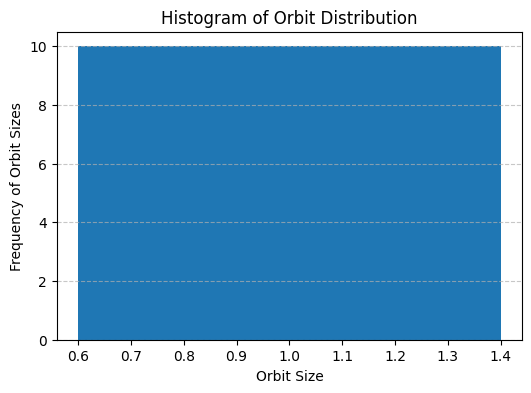

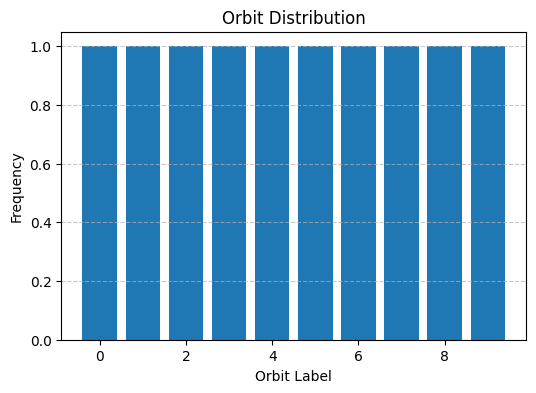

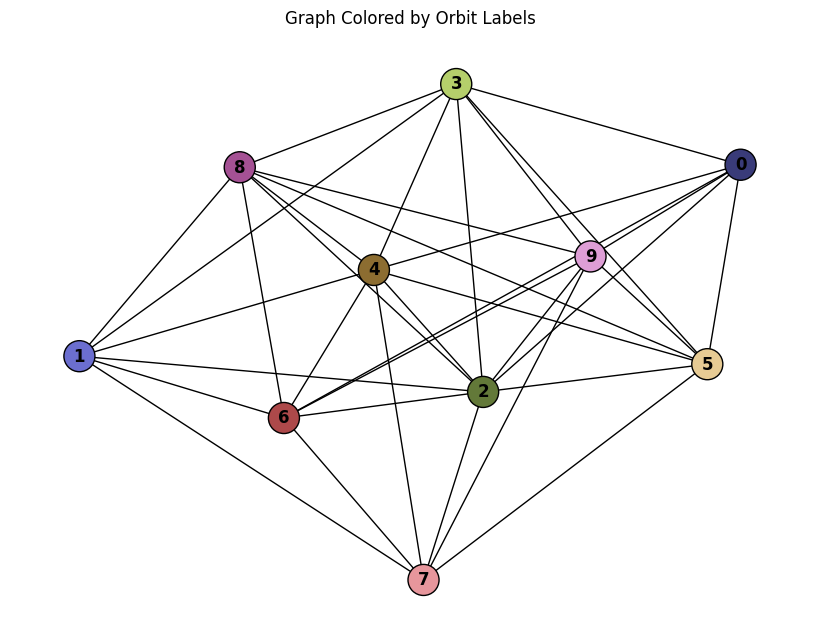

Intra-orbit edges: 1, Inter-orbit edges: 70


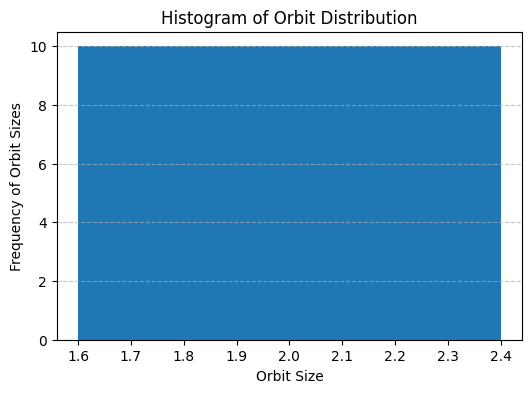

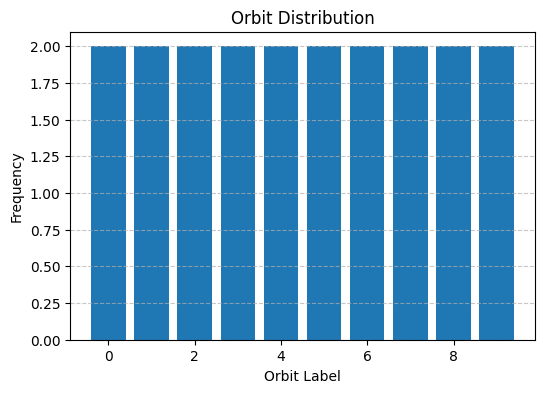

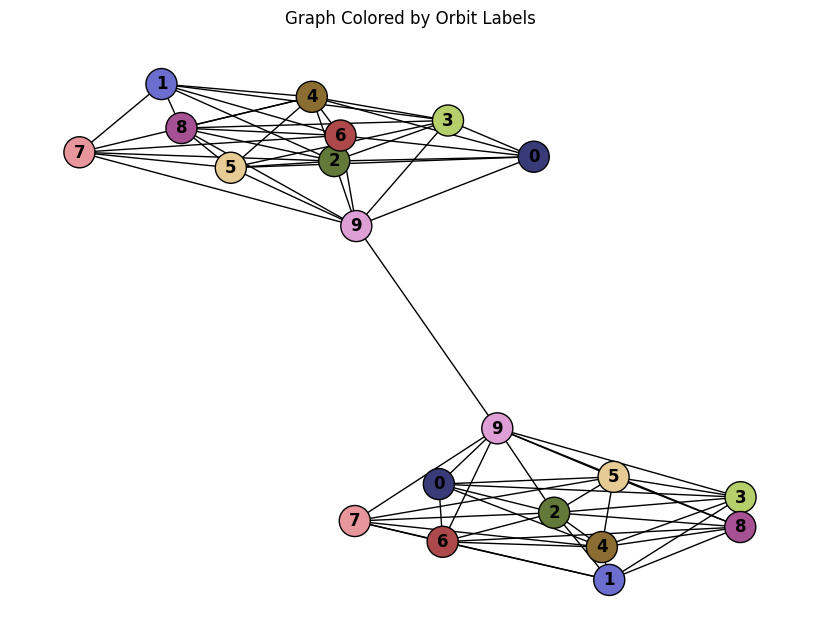

In [ ]:
semi_autom_test(10, GraphType.BARABASI_ALBERT)

